## Feature Engineering

### Realisation

I realised that I have to feature engineer before scaling, since I didn't realise that scaling caused for my data to be placed within a range from 0-1. So, I have decided to save my initial wrangled data and merge it with the new features that I'll create and scale here.

### Import dependencies

In [25]:
import pandas as pd

### Store CSV as variable

In [26]:
data_frame = pd.read_csv("2.2.1.engineering_val_ds.csv")

### Remove Duplicates and Outliers again

In [27]:
# Remove Duplicates
data_frame = data_frame.drop_duplicates()
data_frame.duplicated().sum()

np.int64(0)

In [28]:
#Remove outliers
# Identify IQR for kills_total to highlight outliers
Q1 = data_frame["kills_total"].quantile(0.25)
Q3 = data_frame["kills_total"].quantile(0.75)
IQR = Q3 - Q1
print(
    f"Outliers are a kills_total above {(Q3 + IQR * 1.5):.2f} or below {(Q1 - IQR * 1.5):.2f}"
)
# Adjust range to IQR
data_frame = data_frame[
    (data_frame["kills_total"] >= Q1 - 1.5 * IQR)
    & (data_frame["kills_total"] <= Q3 + 1.5 * IQR)
]

# Identify IQR for wins_total to highlight outliers
Q1 = data_frame["wins_total"].quantile(0.25)
Q3 = data_frame["wins_total"].quantile(0.75)
IQR = Q3 - Q1
print(
    f"Outliers are a wins_total above {(Q3 + IQR * 1.5):.2f} or below {(Q1 - IQR * 1.5):.2f}"
)
# Adjust range to IQR
data_frame = data_frame[
    (data_frame["wins_total"] >= Q1 - 1.5 * IQR)
    & (data_frame["wins_total"] <= Q3 + 1.5 * IQR)
]

# Identify IQR for matchs_played to highlight outliers
Q1 = data_frame["matchs_played"].quantile(0.25)
Q3 = data_frame["matchs_played"].quantile(0.75)
IQR = Q3 - Q1
print(
    f"Outliers are a matchs_played above {(Q3 + IQR * 1.5):.2f} or below {(Q1 - IQR * 1.5):.2f}"
)
# Adjust range to IQR
data_frame = data_frame[
    (data_frame["matchs_played"] >= Q1 - 1.5 * IQR)
    & (data_frame["matchs_played"] <= Q3 + 1.5 * IQR)
]

# Identify IQR for k/d to highlight outliers
Q1 = data_frame["k/d"].quantile(0.25)
Q3 = data_frame["k/d"].quantile(0.75)
IQR = Q3 - Q1
print(
    f"Outliers are a k/d above {(Q3 + IQR * 1.5):.2f} or below {(Q1 - IQR * 1.5):.2f}"
)
# Adjust range to IQR
data_frame = data_frame[
    (data_frame["k/d"] >= Q1 - 1.5 * IQR) & (data_frame["k/d"] <= Q3 + 1.5 * IQR)
]

# Identify IQR for dmg/rnd to highlight outliers
Q1 = data_frame["dmg/rnd"].quantile(0.25)
Q3 = data_frame["dmg/rnd"].quantile(0.75)
IQR = Q3 - Q1
print(
    f"Outliers are a dmg/rnd above {(Q3 + IQR * 1.5):.2f} or below {(Q1 - IQR * 1.5):.2f}"
)
# Adjust range to IQR
data_frame = data_frame[
    (data_frame["dmg/rnd"] >= Q1 - 1.5 * IQR)
    & (data_frame["dmg/rnd"] <= Q3 + 1.5 * IQR)
]

# Identify IQR for win% to highlight outliers
Q1 = data_frame["win%"].quantile(0.25)
Q3 = data_frame["win%"].quantile(0.75)
IQR = Q3 - Q1
print(
    f"Outliers are a win% above {(Q3 + IQR * 1.5):.2f} or below {(Q1 - IQR * 1.5):.2f}"
)
# Adjust range to IQR
data_frame = data_frame[
    (data_frame["win%"] >= Q1 - 1.5 * IQR) & (data_frame["win%"] <= Q3 + 1.5 * IQR)
]

# Identify IQR for headshot_% to highlight outliers
Q1 = data_frame["headshot_%"].quantile(0.25)
Q3 = data_frame["headshot_%"].quantile(0.75)
IQR = Q3 - Q1
print(
    f"Outliers are a headshot_% above {(Q3 + IQR * 1.5):.2f} or below {(Q1 - IQR * 1.5):.2f}"
)
# Adjust range to IQR
data_frame = data_frame[
    (data_frame["headshot_%"] >= Q1 - 1.5 * IQR)
    & (data_frame["headshot_%"] <= Q3 + 1.5 * IQR)
]

# Identify IQR for avg_kill_per_rnd to highlight outliers
Q1 = data_frame["avg_kill_per_rnd"].quantile(0.25)
Q3 = data_frame["avg_kill_per_rnd"].quantile(0.75)
IQR = Q3 - Q1
print(
    f"Outliers are a avg_kill_per_rnd above {(Q3 + IQR * 1.5):.2f} or below {(Q1 - IQR * 1.5):.2f}"
)
# Adjust range to IQR
data_frame = data_frame[
    (data_frame["avg_kill_per_rnd"] >= Q1 - 1.5 * IQR)
    & (data_frame["avg_kill_per_rnd"] <= Q3 + 1.5 * IQR)
]

Outliers are a kills_total above 27350.38 or below -12628.62
Outliers are a wins_total above 747.75 or below -326.25
Outliers are a matchs_played above 1437.50 or below -622.50
Outliers are a k/d above 1.54 or below 0.58
Outliers are a dmg/rnd above 193.15 or below 91.75
Outliers are a win% above 73.90 or below 29.10
Outliers are a headshot_% above 29.73 or below 3.12
Outliers are a avg_kill_per_rnd above 0.95 or below 0.55


### Begin Feature Engineering

This section requires domain specific knowledge and the ability to understand why I am combining specific features which will be explained as I develop them. The main goal is to create a "Performance" feature amongst other minor ones such as "Experience" if I have to. This will be compared against the target 'win%' to hopefully simplify the algorithm also allowing to me test different models beyond just multi-feature linear regression.

I'll start by combining `k/d` and `dmg/rnd` to create an amplified number.

In [29]:
# Create dmg_indicator Feature
data_frame['dmg_indicator'] = (data_frame['k/d'] * data_frame["dmg/rnd"]).round(2)

# Create consistency Feature
data_frame["consistency"] = data_frame["wins_total"] / data_frame["matchs_played"]

# Create performance feature based off of dmg_indicator and consistency respective to matchs_played
data_frame["performance"] = (
    data_frame["dmg_indicator"]
    * data_frame["consistency"]
) * 10

# Create skill feature
data_frame['skill'] = (data_frame['headshot_%'] * data_frame['avg_kill_per_rnd'])


data_frame.describe()

,win%,k/d,dmg/rnd,matchs_played,headshot_%,wins_total,kills_total,avg_kill_per_rnd,dmg_indicator,consistency,performance,skill
count,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.00000,421.000000,421.000000,421.000000,421.000000,421.000000
mean,51.347506,1.056580,143.609264,467.444181,16.734204,232.311164,7185.32304,0.737767,153.960903,0.493491,761.075424,12.488812
std,8.069512,0.153938,17.000137,344.655742,4.525138,171.130932,5389.74433,0.084367,38.548949,0.034674,204.219816,4.125850
min,30.800000,0.590000,94.800000,6.000000,7.700000,2.000000,77.00000,0.600000,63.520000,0.310345,303.854214,4.980000
25%,46.200000,0.950000,131.200000,202.000000,13.400000,100.000000,2887.00000,0.700000,127.890000,0.480315,633.078947,9.310000
50%,51.100000,1.050000,145.000000,389.000000,16.100000,195.000000,5922.00000,0.700000,152.540000,0.495487,749.090323,12.080000
75%,56.500000,1.150000,154.600000,675.000000,19.700000,331.000000,10617.00000,0.800000,177.840000,0.511161,877.793103,15.260000
max,73.300000,1.500000,190.100000,1417.000000,29.600000,713.000000,23055.00000,0.900000,270.560000,0.600000,1477.440000,24.570000


### Check for NULL values

In [30]:
data_frame.isnull().sum()

win%                0
k/d                 0
dmg/rnd             0
matchs_played       0
headshot_%          0
wins_total          0
kills_total         0
avg_kill_per_rnd    0
rank_Ascendant      0
rank_Bronze         0
rank_Diamond        0
rank_Gold           0
rank_Immortal       0
rank_Iron           0
rank_Platinum       0
rank_Radiant        0
rank_Silver         0
rank_Unranked       0
dmg_indicator       0
consistency         0
performance         0
skill               0
dtype: int64

### Remove outliers for new features

I adapted the previous structure to a loop to save space and make code more comprehensible. I would fix the code in data_wrangling although I think its best that I show I've made this development so I'll leave it.

In [31]:
features = ['performance', 'consistency', 'skill', 'dmg_indicator']

for feature in features:
    Q1 = data_frame[feature].quantile(0.25)
    Q3 = data_frame[feature].quantile(0.75)
    IQR = Q3 - Q1
    print(f"Outliers for {feature} are above {(Q3 + IQR * 1.5):.2f} or below {(Q1 - IQR * 1.5):.2f}")
    data_frame = data_frame[
        (data_frame[feature] >= Q1 - 1.5 * IQR)
        & (data_frame[feature] <= Q3 + 1.5 * IQR)
    ]

data_frame.describe()

Outliers for performance are above 1244.86 or below 266.01
Outliers for consistency are above 0.56 or below 0.43
Outliers for skill are above 23.58 or below 0.97
Outliers for dmg_indicator are above 242.52 or below 59.13


,win%,k/d,dmg/rnd,matchs_played,headshot_%,wins_total,kills_total,avg_kill_per_rnd,dmg_indicator,consistency,performance,skill
count,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000
mean,51.519634,1.047277,142.607068,496.044503,16.684293,246.502618,7599.212042,0.735602,151.272016,0.496506,751.088997,12.389791
std,7.848547,0.143116,16.037626,342.498923,4.360033,169.865869,5361.199195,0.081582,35.264210,0.022099,178.660593,3.888110
min,32.000000,0.590000,94.800000,6.000000,7.700000,3.000000,89.000000,0.600000,63.520000,0.434483,303.854214,4.980000
25%,46.325000,0.950000,131.200000,232.000000,13.500000,117.000000,3377.000000,0.700000,127.895000,0.482295,636.950849,9.450000
50%,51.200000,1.050000,144.300000,413.000000,16.150000,210.000000,6175.500000,0.700000,150.500000,0.496063,748.611036,12.040000
75%,56.500000,1.140000,153.800000,706.750000,19.500000,350.750000,10971.000000,0.800000,173.620000,0.510525,869.643805,14.975000
max,73.300000,1.410000,184.500000,1417.000000,28.200000,713.000000,23055.000000,0.900000,241.160000,0.553333,1239.362069,22.680000


### Scale new features

In [32]:
features = ["performance", "consistency", "skill", "dmg_indicator"]
MAX_v = [1250, 1, 25, 300]
MIN_v = [200, 0, 0, 0]

i = 0

for feature in features:
    data_frame[feature] = (data_frame[feature] - MIN_v[i]) / (
    MAX_v[i] - MIN_v[i])
    i+=1

data_frame.describe()
data_frame.isnull().sum()

win%                0
k/d                 0
dmg/rnd             0
matchs_played       0
headshot_%          0
wins_total          0
kills_total         0
avg_kill_per_rnd    0
rank_Ascendant      0
rank_Bronze         0
rank_Diamond        0
rank_Gold           0
rank_Immortal       0
rank_Iron           0
rank_Platinum       0
rank_Radiant        0
rank_Silver         0
rank_Unranked       0
dmg_indicator       0
consistency         0
performance         0
skill               0
dtype: int64

### Heatmap

I'm going to use a heatmap to interpret new feature's viability with original features, this can be used for quick information during Model Training to identify the most suitable features for comparison. This also gives insight on whether I need to re-evaluate my engineered features.

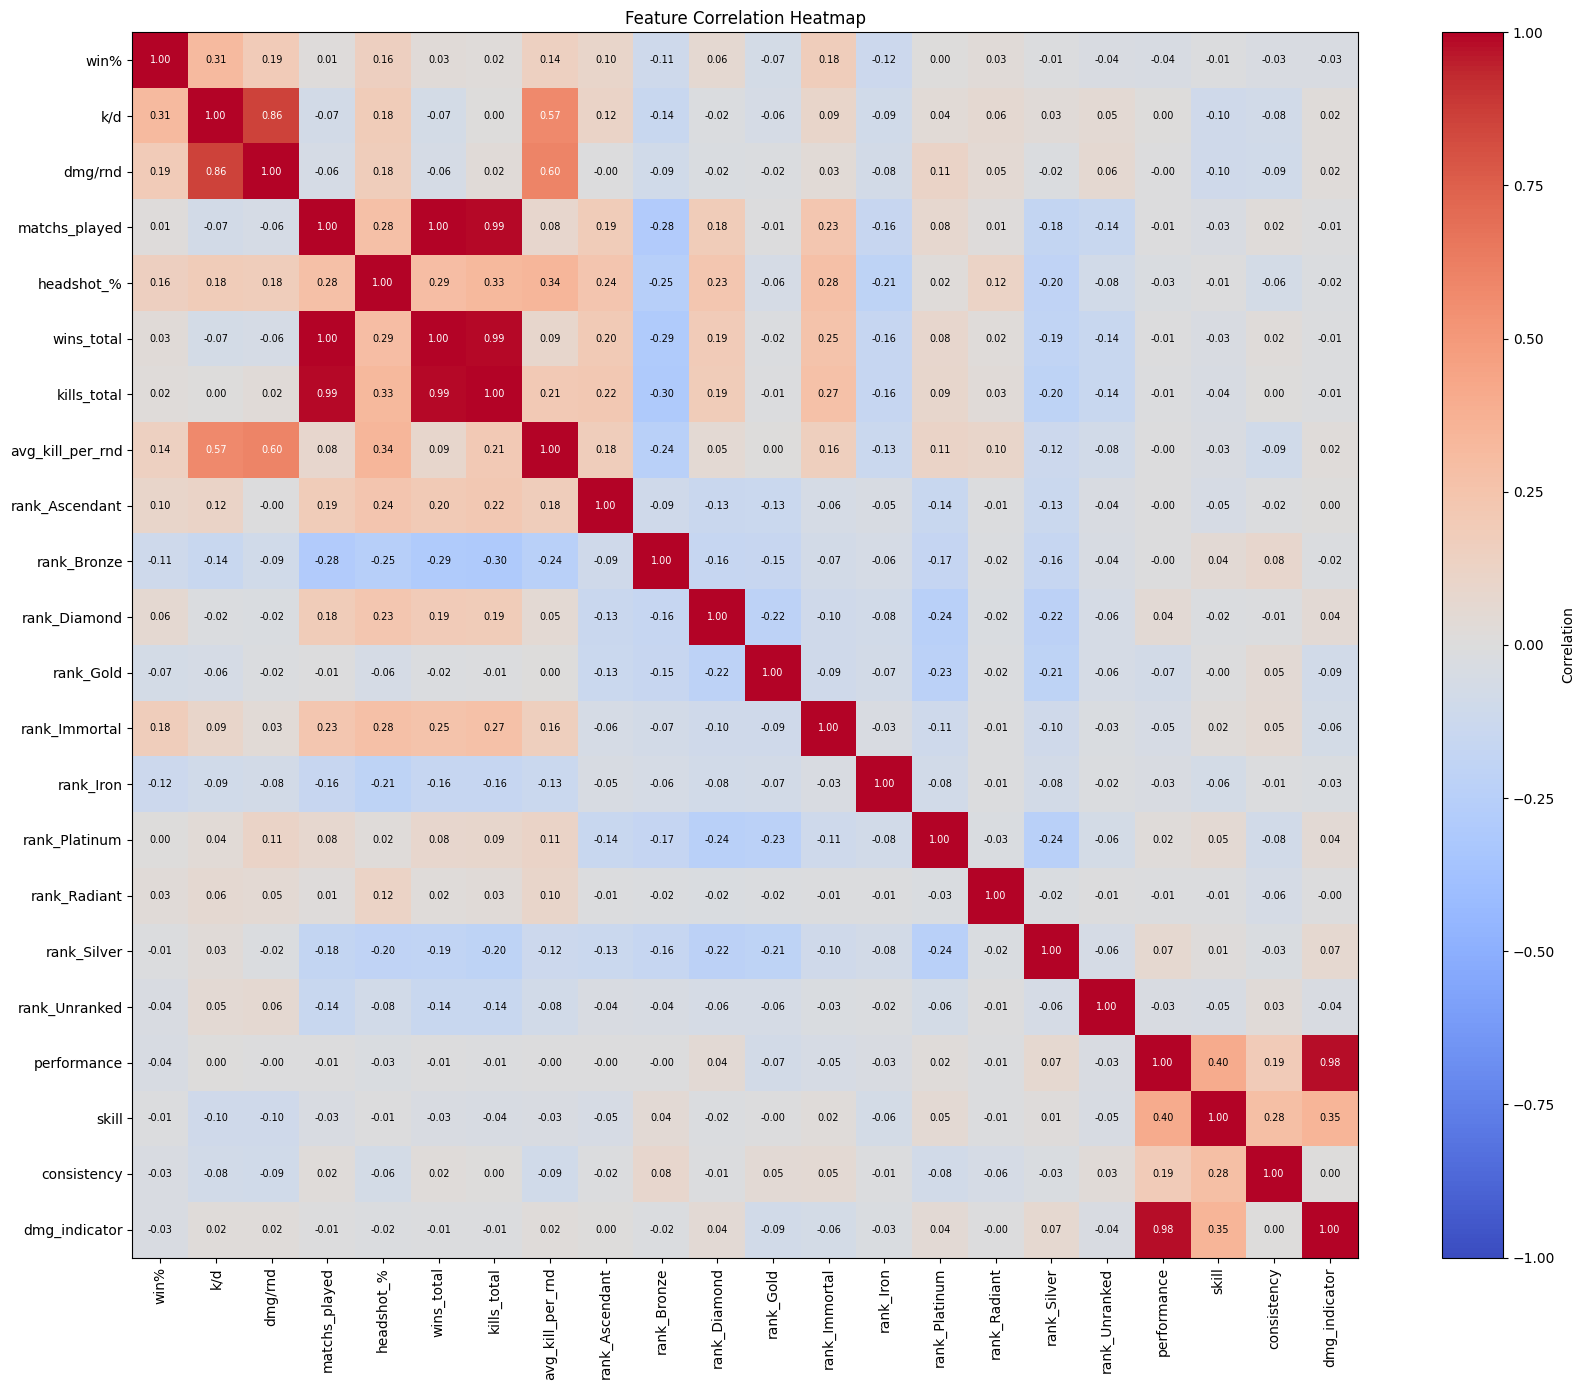

In [33]:
# ...existing code...
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
df = pd.read_csv(
    "/workspaces/2026SE_MLOOPs_Gerrard.F/2. Model_Development/2.3.Model_Training/2.3.1.final_val_ds.csv"
)

# Keep numeric + boolean columns for correlation
corr_df = df.select_dtypes(include=["number", "bool"]).copy()
corr_df = corr_df.apply(lambda col: col.astype(int) if col.dtype == "bool" else col)

# Correlation matrix
corr = corr_df.corr(numeric_only=True)
labels = corr.columns
matrix = corr.values

# Plot heatmap (matplotlib only)
fig, ax = plt.subplots(figsize=(18, 14))
im = ax.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)

# Axis labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)
ax.set_title("Feature Correlation Heatmap")

# Add numbers in each cell
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix[i, j]
        text_color = "white" if abs(value) > 0.5 else "black"
        ax.text(
            j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=7
        )

# Color bar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlation")

plt.tight_layout()
plt.show()
# ...existing code...

### Further feature analysis

I found out later on that using multiple classes for logistic regression was not optimal and that some of my previous code wasn't properly functioning and merging the ranks as I wanted it to. So here I'll check and evaluate the ranks, finding the median rank. From there, I can state whether your performance in correlation to that rank is good or not; ultimately determining a player's MMR.

In [34]:
print("Rows in dataset:", len(data_frame1))

# Rank columns
rank_cols = [c for c in data_frame1.columns if c.startswith("rank_")]

# Group duplicates by stripped name (e.g., "rank_Silver" + "rank_Silver ")
rank_groups = {}
for c in rank_cols:
    rank_groups.setdefault(c.strip(), []).append(c)

# Merge duplicate rank columns with OR logic
rank_flags_merged = pd.DataFrame(
    {k: data_frame1[v].astype(bool).any(axis=1) for k, v in rank_groups.items()}
)

# Aggregate counts per rank (number of True rows)
rank_totals = rank_flags_merged.sum().sort_values(ascending=False).astype(int)
print("\nAggregated rank counts:")
print(rank_totals)

# Optional: percentage
print("\nAggregated rank percentages:")
print((rank_totals / len(rank_flags_merged) * 100).round(2))

# Ordered rank scale (lowest -> highest)
rank_order = [
    "rank_Unranked",
    "rank_Iron",
    "rank_Bronze",
    "rank_Silver",
    "rank_Gold",
    "rank_Platinum",
    "rank_Diamond",
    "rank_Ascendant",
    "rank_Immortal",
    "rank_Radiant",
]

# Keep only ranks that exist in your merged frame
rank_order_present = [r for r in rank_order if r in rank_flags_merged.columns]
if not rank_order_present:
    raise ValueError("No rank columns found in rank_flags_merged.")

# Count players per rank using merged rank flags
counts = rank_flags_merged[rank_order_present].sum().astype(int)

# Weighted median rank (by cumulative counts)
total = int(counts.sum())
half = total / 2
cum = counts.cumsum()
median_rank_col = cum[cum >= half].index[0]
median_rank = median_rank_col.replace("rank_", "")

print("Total labeled players:", total)
print("Rank counts:\n", counts)
print("Median rank:", median_rank)


Rows in dataset: 421

Aggregated rank counts:
rank_Platinum     82
rank_Diamond      81
rank_Silver       71
rank_Gold         71
rank_Bronze       43
rank_Ascendant    33
rank_Immortal     19
rank_Iron         12
rank_Unranked      8
rank_Radiant       1
dtype: int64

Aggregated rank percentages:
rank_Platinum     19.48
rank_Diamond      19.24
rank_Silver       16.86
rank_Gold         16.86
rank_Bronze       10.21
rank_Ascendant     7.84
rank_Immortal      4.51
rank_Iron          2.85
rank_Unranked      1.90
rank_Radiant       0.24
dtype: float64
Total labeled players: 421
Rank counts:
 rank_Unranked      8
rank_Iron         12
rank_Bronze       43
rank_Silver       71
rank_Gold         71
rank_Platinum     82
rank_Diamond      81
rank_Ascendant    33
rank_Immortal     19
rank_Radiant       1
dtype: int64
Median rank: Platinum


### Combine new features into data_wrangled csv

In [35]:
# Load pre-existing csv
data_frame1 = pd.read_csv("2.2.1.wrangled_val_ds.csv")

# Extract new features
features = data_frame[
    ["performance", "skill", "consistency", "dmg_indicator"]
].reset_index(drop=True)

data_frame1 = data_frame1.reset_index(drop=True)

new_data_frame = pd.concat([data_frame1, features], axis=1)

# Fixes potentially indexing errors that will result in NULL values
required_cols = ["win%", "performance", "skill", "consistency", "dmg_indicator"]
new_data_frame = new_data_frame.dropna(subset=required_cols).reset_index(drop=True)

new_data_frame.to_csv("../2.3.Model_Training/2.3.1.final_val_ds.csv", index=False)
print("Merge Complete")

Merge Complete
